# Phase Estimation
* The eigen values of a unitary matrix $U$ are of the form $e^{2\pi i\varphi}$, naturally $0\leq \varphi < 1$
* Many key algorithms reduce to finding $\varphi$.
* Given an eigenvector $|u\rangle$, a key step is implementing controlled $U^j$ gates, controlled by $|j\rangle$.
* Idea is to apply $U^{2^k}$ gate controlled by the $kth$ bit of $j$.

# Pseudocode
$$\begin{align}
|u\rangle|0\rangle \xrightarrow{H^{\otimes t}}& \frac{1}{\sqrt{2^t}}{\sum_{j=0}^{2^t -1}}|u\rangle|j\rangle\\
\xrightarrow{controlled-U^j}&\frac{1}{\sqrt{2^t}}{\sum_{j=0}^{2^t -1}}U^j|u\rangle|j\rangle\\
&=|u\rangle\frac{1}{\sqrt{2^t}}{\sum_{j=0}^{2^t -1}}e^{2\pi ij\varphi}|j\rangle\\
\xrightarrow{QFT^{\dagger}}&|u\rangle|\varphi_t\rangle\\
\xrightarrow{measure~|\varphi_t\rangle}& \varphi_t
\end{align}$$
* Here $\varphi_t$ is $t$-bit approximation of $\varphi$.

## Qiskit implimentation 
* $U$ is usually treated as a block box.
* We need to sample a random unitary gate $U$ and need to know it's eigen vector $|u\rangle$.
* We can escape needing to know $|u\rangle$, by starting with $$|0\rangle = \sum_u \alpha_u|u\rangle$$ where the sum is over all eigen vectors of $U$.
* That is, we start with $|0\rangle$ instead of $|u\rangle$.
* In this case we obtain $t$ bit approximation of eigenvalue of an arbitrary eigenvector of $U$.

# Controlled $U^j$ gates
* Controlled gates can be written as $$C^tU = \sum_{j=0}^{2^t-1}|j\rangle\langle j|\otimes U_j$$
* In qiskit it would be $$C^tU = \sum_{j=0}^{2^t-1}U_j\otimes |j\rangle\langle j|$$
* In qiskit, these are called Uniformly controlled gates defined by gate `UCGate` in `qiskit.circuit.library` 
* In the phase estimation case, we have $$U_j = U^j$$

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT, UCRXGate

In [2]:
# --- Parameters ---
N_COUNT = 4              # Number of counting qubits (precision)
THETA = np.pi / 3        # Angle for Rx gate (e.g., 60 degrees)
PHI = THETA / (4 * np.pi) # Theoretical phase: phi = (theta/2) / (2pi)

# --- Define the Sequence of Controlled Angles ---
# We need the list of angles for UCRXGate: [R_x(0*theta), R_x(1*theta), ..., R_x((2^N - 1)*theta)]
angles_list = [k * THETA for k in range(2**N_COUNT)]

In [3]:


# --- Circuit Setup ---
qc = QuantumCircuit(N_COUNT + 1, N_COUNT)
c_qubits = list(range(N_COUNT)) # Counting register (Controls)
t_qubit = N_COUNT               # Target qubit

# 1. State Preparation
# Initialize target qubit to the eigenvector |+> = H|0>
qc.h(t_qubit)

# Apply Hadamard gates to the counting qubits to create superposition
qc.h(c_qubits)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [4]:


# 2. Uniformly Controlled Operation (The UC Gate)
# The UCRXGate applies R_x(k*theta) to the target qubit when controls are in state |k>
# Note: UCRXGate takes the angles in reverse order for Qiskit's little-endian convention.
# However, for a simple rotation angle list, we can keep the order and rely on Qiskit's mapping.
# The gate definition is: UCRXGate(angle_list, control_qubits_list)
uc_gate = UCRXGate(angles_list)
uc_gate.definition = None
uc_gate.name = "CU"
uc_gate.label = "C-Uj"
# uc_gate = uc_gate0.to_instruction(label="$C_j-U^j$")


In [5]:


# We append the UC gate, mapping the control qubits (c_qubits) and the target qubit (t_qubit)
# The UC gate acts on all N_COUNT + 1 qubits.

qc.append(uc_gate, c_qubits + [t_qubit])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [6]:
# 3. Inverse Quantum Fourier Transform (IQFT)
qc.append(QFT(N_COUNT, inverse=True).to_gate(), c_qubits)


C:\Users\drmit\AppData\Local\Temp\ipykernel_21340\2249536312.py:2: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(N_COUNT, inverse=True).to_gate(), c_qubits)


<IPython.core.display.Latex object>

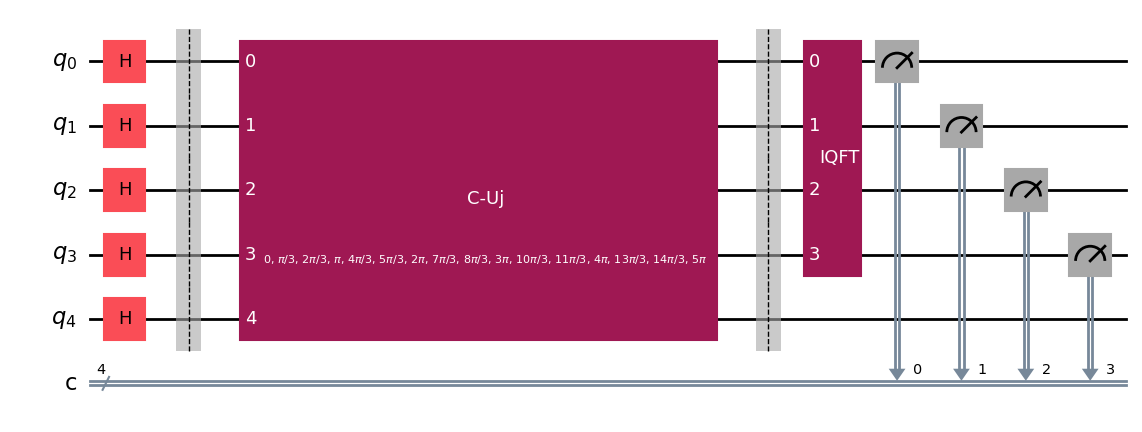

In [7]:
display(Statevector(qc).draw('latex'))
# 4. Measurement
qc.measure(c_qubits, range(N_COUNT))
display(qc.draw("mpl"))
